In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path_file = f'loan_data_total.csv'
df_loan = pd.read_csv(path_file, sep=';', low_memory=False)

In [3]:


# Lista completa
variaveis_explicativas = [
    "valor_financiado",
    "finalidade_emprestimo",  # categórica (não entra)
    "taxa_juros",
    "valor_parcela",
    "tempo_relacionamento",
    "escore_fico",
    "inadimplencia_2anos",
    "registros_publicos_negativos",
    "renda_mensal",
    "compm_renda"
]

# Selecionar apenas variáveis numéricas
variaveis_numericas = [
    "valor_financiado",
    "taxa_juros",
    "tempo_relacionamento",
    "escore_fico",
    "inadimplencia_2_anos",
    "registros_publicos_negativos",
    "renda_mensal",
]

df_corr = df_loan[variaveis_numericas].dropna()

# Matriz de correlação de Pearson
matriz_corr = df_corr.corr(method="pearson")

# Exibir no console
print(matriz_corr.round(3))

                              valor_financiado  taxa_juros  \
valor_financiado                         1.000      -0.089   
taxa_juros                              -0.089       1.000   
tempo_relacionamento                     0.151      -0.136   
escore_fico                              0.102      -0.453   
inadimplencia_2_anos                    -0.009       0.075   
registros_publicos_negativos            -0.055       0.052   
renda_mensal                             0.257      -0.082   

                              tempo_relacionamento  escore_fico  \
valor_financiado                             0.151        0.102   
taxa_juros                                  -0.136       -0.453   
tempo_relacionamento                         1.000        0.113   
escore_fico                                  0.113        1.000   
inadimplencia_2_anos                         0.086       -0.178   
registros_publicos_negativos                 0.063       -0.184   
renda_mensal                      

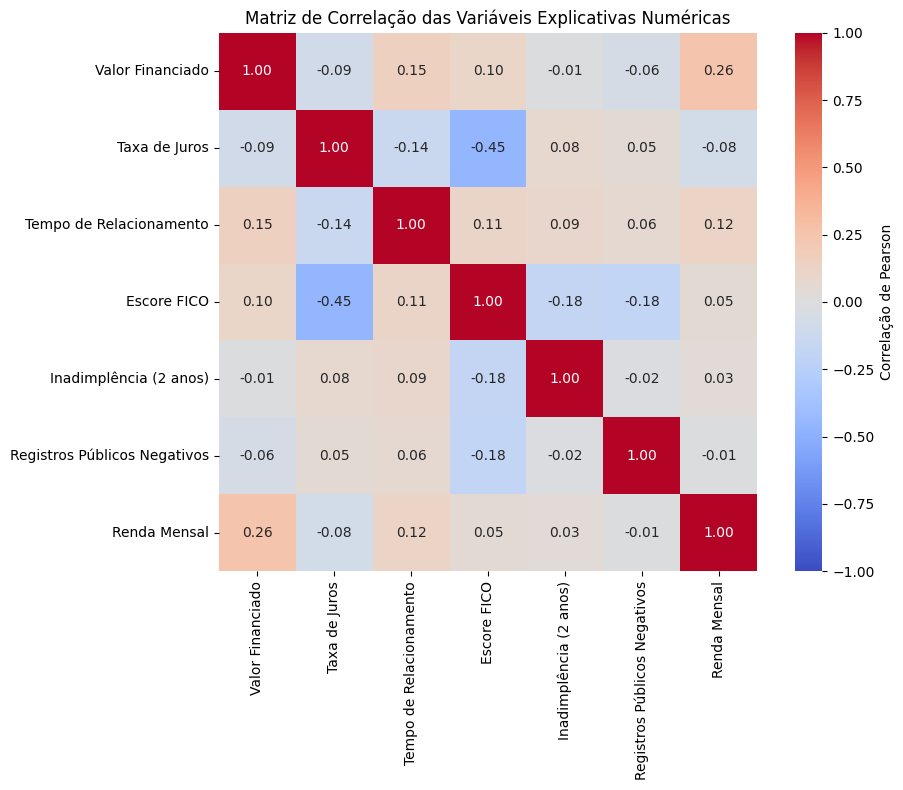

In [4]:
nomes_variaveis = {
    "valor_financiado": "Valor Financiado",
    "taxa_juros": "Taxa de Juros",
    "tempo_relacionamento": "Tempo de Relacionamento",
    "escore_fico": "Escore FICO",
    "inadimplencia_2_anos": "Inadimplência (2 anos)",
    "registros_publicos_negativos": "Registros Públicos Negativos",
    "renda_mensal": "Renda Mensal"
}

matriz_corr = matriz_corr.rename(index=nomes_variaveis, columns=nomes_variaveis)

plt.figure(figsize=(10,8))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,      # limite inferior
    vmax=1,       # limite superior
    center=0,
    square=True,
    cbar_kws={"label": "Correlação de Pearson"}
)

plt.title("Matriz de Correlação das Variáveis Explicativas Numéricas")
plt.tight_layout()
plt.savefig('figuras/matriz_correlacao_variaveis_numericas_limpo.png', dpi=600, bbox_inches='tight')
plt.show()

In [5]:
print(type(matriz_corr))

<class 'pandas.DataFrame'>
